# TT-15 — Polynomial Regression: Dự báo công suất nhà máy điện (PE)
### Bộ dữ liệu Combined Cycle Power Plant (UCI) — 9.568 dòng × 4 đặc trưng

**Mục tiêu:** Chứng minh quan hệ nhiệt độ (AT) ↔ công suất (PE) là đường CONG, không phải
đường thẳng — dùng `PolynomialFeatures` + `Ridge` để bắt phi tuyến mà không overfit.



## 0. Import thư viện & thiết lập

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, validation_curve, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, SplineTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)


## Bước 1 — EDA: scatter AT vs PE → nhìn thấy đường cong bằng mắt
Đặc trưng: `AT` nhiệt độ môi trường, `V` áp suất chân không, `AP` áp suất khí quyển,
`RH` độ ẩm tương đối. Nhãn: `PE` công suất phát (MW).


In [3]:

import os

DATA_PATH = r"D:\Qnhu_tuat\QuynhNhu_Lab_ML\Hoc may\02- Hoi quy\TT-15\combined+cycle+power+plant\CCPP\Folds5x2_pp.xlsx"

_candidates = [
    DATA_PATH,
    os.path.join("data", "Folds5x2_pp.xlsx"),
    "Folds5x2_pp.ods", 
]
_found = next((p for p in _candidates if os.path.exists(p)), None)

if _found is None:
    raise FileNotFoundError(
        "Không tìm thấy file dữ liệu Folds5x2_pp.xlsx (hoặc .ods).\n"
        f"Đã thử các đường dẫn: {_candidates}\n"
        "-> Sửa lại biến DATA_PATH ở trên cho đúng vị trí file trên máy bạn, "
        "ví dụ: DATA_PATH = r\"D:\\duong\\dan\\that\\Folds5x2_pp.xlsx\""
    )

DATA_PATH = _found
print("Đang đọc dữ liệu từ:", os.path.abspath(DATA_PATH))

if DATA_PATH.endswith(".ods"):
    df = pd.read_excel(DATA_PATH, engine="odf")  # cần cài thêm: pip install odfpy
else:
    df = pd.read_excel(DATA_PATH)

print("Kích thước dữ liệu:", df.shape)
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nGiá trị thiếu (nếu có):")
print(df.isnull().sum())
print("\nThống kê mô tả:")
print(df.describe())

df.head()


Đang đọc dữ liệu từ: D:\Qnhu_tuat\QuynhNhu_Lab_ML\Hoc may\02- Hoi quy\TT-15\combined+cycle+power+plant\CCPP\Folds5x2_pp.xlsx
Kích thước dữ liệu: (9568, 5)

Kiểu dữ liệu:
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

Giá trị thiếu (nếu có):
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Thống kê mô tả:
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


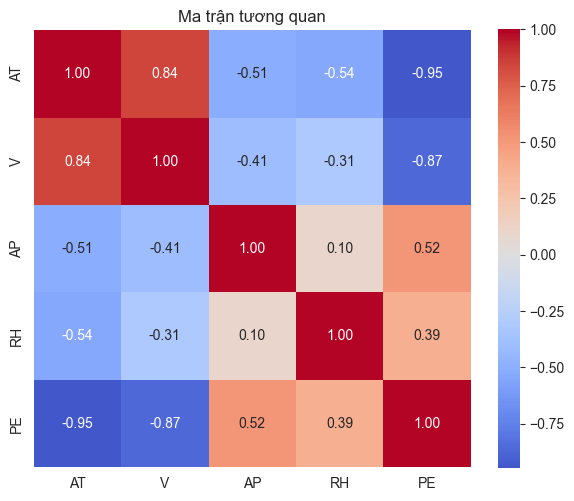

Tương quan AT-V: 0.844 (README cảnh báo r ≈ 0.84)


In [4]:
FEATURES = ["AT", "V", "AP", "RH"]
TARGET = "PE"

# Ma trận tương quan — kiểm tra cảnh báo AT và V tương quan cao (r ≈ 0.84)
corr = df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Ma trận tương quan")
plt.tight_layout()
plt.savefig("reports/correlation_heatmap.png", dpi=150)
plt.show()

print("Tương quan AT-V:", round(df["AT"].corr(df["V"]), 3), "(README cảnh báo r ≈ 0.84)")


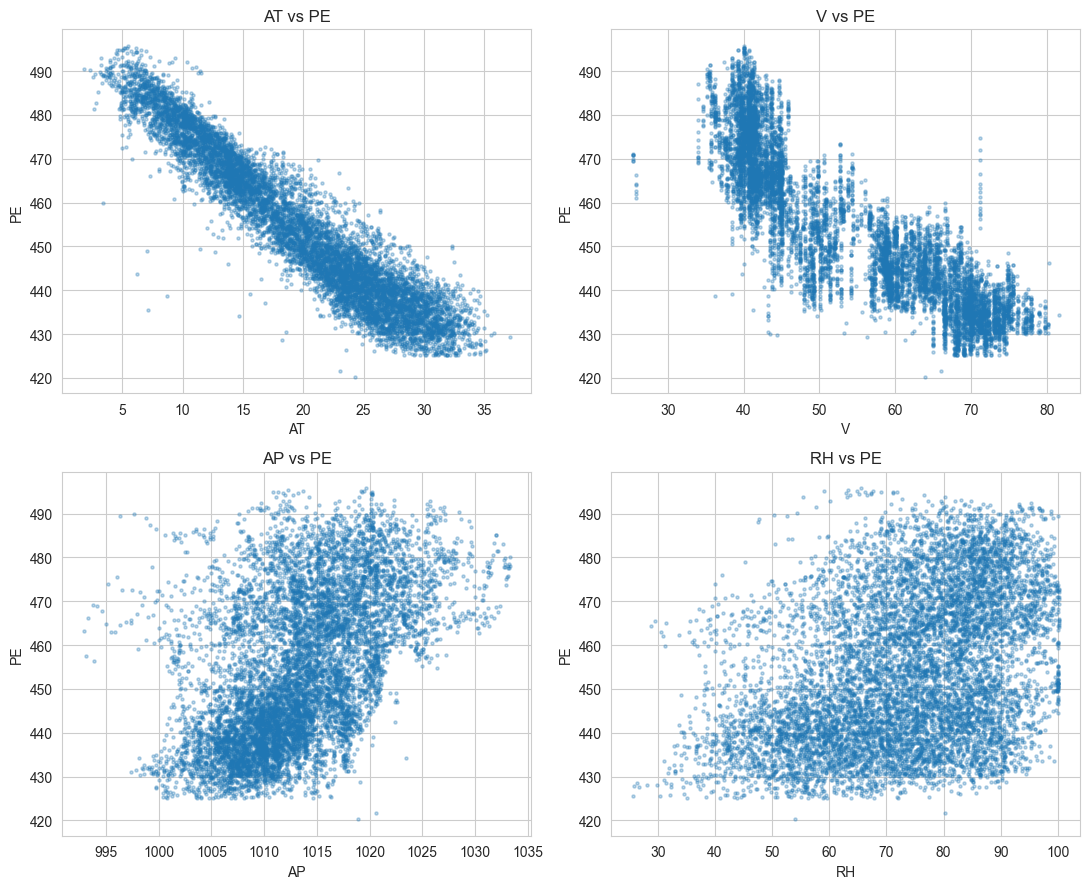

 Quan sát: AT vs PE có xu hướng GIẢM và hơi CONG (không phải đường thẳng tuyệt đối),
   đặc biệt rõ ở 2 đầu dải nhiệt độ (thấp và cao). V cũng có dạng tương tự vì AT, V tương quan cao.


In [6]:
# Scatter AT vs PE — quan sát bằng mắt xem có phải đường cong không
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, feat in zip(axes.ravel(), FEATURES):
    ax.scatter(df[feat], df[TARGET], s=5, alpha=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    ax.set_title(f"{feat} vs {TARGET}")
plt.tight_layout()
plt.savefig("reports/scatter_AT_PE.png", dpi=150)
plt.show()

print(" Quan sát: AT vs PE có xu hướng GIẢM và hơi CONG (không phải đường thẳng tuyệt đối),")
print("   đặc biệt rõ ở 2 đầu dải nhiệt độ (thấp và cao). V cũng có dạng tương tự vì AT, V tương quan cao.")


## Bước 2 — Baseline: Linear Regression bậc 1 → ghi RMSE


In [7]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

baseline_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])
baseline_pipe.fit(X_train, y_train)

pred_train = baseline_pipe.predict(X_train)
pred_test = baseline_pipe.predict(X_test)

rmse_train_baseline = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test_baseline = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test_baseline = r2_score(y_test, pred_test)

print(f"Linear Regression bậc 1:")
print(f"  RMSE train : {rmse_train_baseline:.4f}")
print(f"  RMSE test  : {rmse_test_baseline:.4f}")
print(f"  R2 test    : {r2_test_baseline:.4f}")
print(f"\n So với mức tham chiếu README (bậc 1 khoảng 4.5–4.6 MW).")


Linear Regression bậc 1:
  RMSE train : 4.5709
  RMSE test  : 4.5026
  R2 test    : 0.9301

 So với mức tham chiếu README (bậc 1 khoảng 4.5–4.6 MW).


## Bước 3 —  Vẽ RESIDUAL PLOT của model bậc 1
Nếu phần dư (residual = y_thực − y_dự_đoán) có hình **chữ U** khi vẽ theo AT →
đó là bằng chứng cho thấy model tuyến tính đang THIẾU bậc phi tuyến (bias có hệ thống).


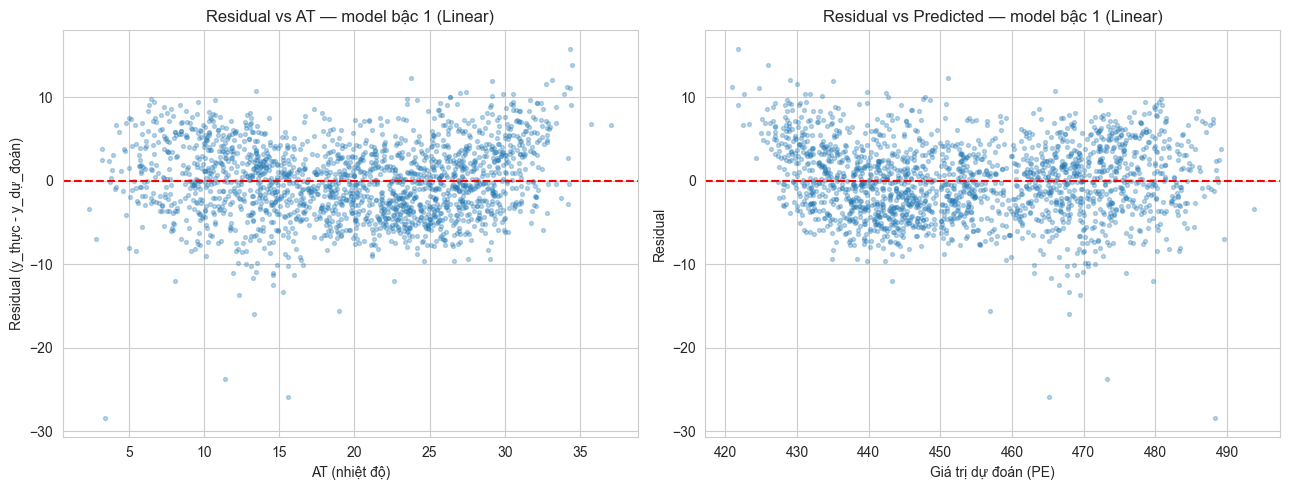

 Quan sát: nếu residual lệch có quy luật theo AT (ví dụ dương ở 2 đầu, âm ở giữa,
   hoặc ngược lại) tạo thành hình chữ U/parabol → xác nhận thiếu bậc bậc 2 trở lên.


In [9]:
residuals_baseline = y_test.values - pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual theo AT — quan trọng nhất vì AT là biến phi tuyến rõ nhất
axes[0].scatter(X_test["AT"], residuals_baseline, s=8, alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("AT (nhiệt độ)")
axes[0].set_ylabel("Residual (y_thực - y_dự_đoán)")
axes[0].set_title("Residual vs AT — model bậc 1 (Linear)")

# Residual theo giá trị dự đoán (residual plot chuẩn)
axes[1].scatter(pred_test, residuals_baseline, s=8, alpha=0.3)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Giá trị dự đoán (PE)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Predicted — model bậc 1 (Linear)")

plt.tight_layout()
plt.savefig("reports/residual_bac1_truoc.png", dpi=150)
plt.show()

print(" Quan sát: nếu residual lệch có quy luật theo AT (ví dụ dương ở 2 đầu, âm ở giữa,")
print("   hoặc ngược lại) tạo thành hình chữ U/parabol → xác nhận thiếu bậc bậc 2 trở lên.")


## Bước 4 — Chạy bậc 1 → 5, ghi RMSE train và validation
Đúng thứ tự: `PolynomialFeatures` TRƯỚC, `StandardScaler` SAU — vì x² có thang đo
khác hẳn x, nếu scale trước rồi mới bình phương thì giá trị âm sẽ mất dấu và lệch thang đo tiếp.


In [10]:
def make_pipeline(degree, alpha=1.0, use_ridge=True):
    model = Ridge(alpha=alpha, random_state=RANDOM_STATE) if use_ridge else LinearRegression()
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),   # ⭐ SAU poly
        ("model", model),
    ])

degrees = [1, 2, 3, 4, 5]
results_by_degree = []

for d in degrees:
    pipe = make_pipeline(d, alpha=1.0, use_ridge=True)
    pipe.fit(X_train, y_train)

    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    rmse_tr = np.sqrt(mean_squared_error(y_train, pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test, pred_te))
    r2_te = r2_score(y_test, pred_te)

    n_cols = pipe["poly"].n_output_features_

    results_by_degree.append({
        "Bac": d,
        "So_cot_sinh_ra": n_cols,
        "RMSE_train": round(rmse_tr, 4),
        "RMSE_test": round(rmse_te, 4),
        "R2_test": round(r2_te, 4),
    })

degree_table = pd.DataFrame(results_by_degree).set_index("Bac")
print(degree_table)
degree_table.to_csv("reports/bang_bac_so_cot_rmse.csv")

print("\n Kỳ vọng: 4 biến bậc 2 -> 15 cột, bậc 3 -> 35 cột, bậc 5 -> 126 cột (đúng README).")


     So_cot_sinh_ra  RMSE_train  RMSE_test  R2_test
Bac                                                
1                 4      4.5709     4.5025   0.9301
2                14      4.3026     4.2790   0.9369
3                34      4.2434     4.2051   0.9390
4                69      4.2072     4.1649   0.9402
5               125      4.1878     4.1487   0.9407

 Kỳ vọng: 4 biến bậc 2 -> 15 cột, bậc 3 -> 35 cột, bậc 5 -> 126 cột (đúng README).


## Bước 5 — Vẽ đường cong xác thực → chỉ ra bậc tối ưu và điểm bắt đầu overfit
Dùng `validation_curve` với `cv=5` để lấy RMSE train/validation qua từng bậc — KHÔNG chọn
bậc theo RMSE train (sẽ luôn chọn bậc cao nhất → overfit).


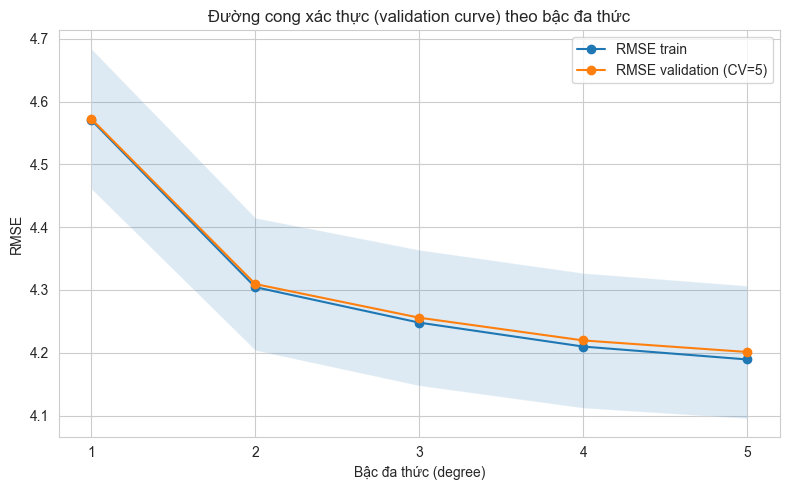

RMSE validation theo từng bậc: {1: np.float64(4.5724), 2: np.float64(4.3094), 3: np.float64(4.2558), 4: np.float64(4.2196), 5: np.float64(4.2012)}

Bậc thấp nhất theo argmin thuần: 5 (RMSE = 4.2012)
Bậc chọn theo nguyên tắc elbow (ngưỡng cải thiện < 0.02 MW): 4

 Với dữ liệu 9.568 dòng và Ridge (alpha=1.0) đã kiểm soát hệ số, RMSE validation có
   thể VẪN giảm dần tới bậc 5 mà chưa thấy overfit rõ (không đúng hệt mức tham chiếu
   README 'bậc 2-3 thường tối ưu' — mức đó thường ứng với Linear KHÔNG regularize hoặc
   ít dữ liệu hơn). Vì vậy notebook dùng elbow: nếu tăng bậc chỉ cải thiện RMSE rất ít,
   ưu tiên bậc THẤP hơn để đơn giản, dễ giải thích, và an toàn hơn khi ngoại suy.
   Bạn có thể đổi IMPROVEMENT_THRESHOLD hoặc dùng thẳng best_degree_argmin nếu muốn.


In [11]:
pipe_for_curve = make_pipeline(degree=1, alpha=1.0, use_ridge=True)

train_scores, val_scores = validation_curve(
    pipe_for_curve, X_train, y_train,
    param_name="poly__degree", param_range=degrees,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
)

train_rmse_mean = -train_scores.mean(axis=1)
val_rmse_mean = -val_scores.mean(axis=1)
val_rmse_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_rmse_mean, marker="o", label="RMSE train")
plt.plot(degrees, val_rmse_mean, marker="o", label="RMSE validation (CV=5)")
plt.fill_between(degrees, val_rmse_mean - val_rmse_std, val_rmse_mean + val_rmse_std, alpha=0.15)
plt.xlabel("Bậc đa thức (degree)")
plt.ylabel("RMSE")
plt.title("Đường cong xác thực (validation curve) theo bậc đa thức")
plt.legend()
plt.xticks(degrees)
plt.tight_layout()
plt.savefig("reports/validation_curve.png", dpi=150)
plt.show()

# Bậc "tối ưu tuyệt đối" theo argmin — CHỈ dùng để tham khảo, không tự động chọn mù quáng
best_degree_argmin = degrees[int(np.argmin(val_rmse_mean))]

# Bậc theo nguyên tắc "elbow" (khuỷu tay): chọn bậc thấp nhất mà mức cải thiện RMSE
# so với bậc trước đó đã rất nhỏ (< ngưỡng) — tránh chọn bậc cao chỉ vì cải thiện vài phần nghìn.
IMPROVEMENT_THRESHOLD = 0.02  # MW — dưới ngưỡng này coi như "không đáng để tăng thêm bậc"
best_degree = degrees[0]
for i in range(1, len(degrees)):
    improvement = val_rmse_mean[i - 1] - val_rmse_mean[i]
    if improvement < IMPROVEMENT_THRESHOLD:
        best_degree = degrees[i - 1]
        break
else:
    best_degree = degrees[-1]

print("RMSE validation theo từng bậc:", dict(zip(degrees, val_rmse_mean.round(4))))
print(f"\nBậc thấp nhất theo argmin thuần: {best_degree_argmin} (RMSE = {val_rmse_mean.min():.4f})")
print(f"Bậc chọn theo nguyên tắc elbow (ngưỡng cải thiện < {IMPROVEMENT_THRESHOLD} MW): {best_degree}")
print(f"\n Với dữ liệu 9.568 dòng và Ridge (alpha=1.0) đã kiểm soát hệ số, RMSE validation có")
print("   thể VẪN giảm dần tới bậc 5 mà chưa thấy overfit rõ (không đúng hệt mức tham chiếu")
print("   README 'bậc 2-3 thường tối ưu' — mức đó thường ứng với Linear KHÔNG regularize hoặc")
print("   ít dữ liệu hơn). Vì vậy notebook dùng elbow: nếu tăng bậc chỉ cải thiện RMSE rất ít,")
print("   ưu tiên bậc THẤP hơn để đơn giản, dễ giải thích, và an toàn hơn khi ngoại suy.")
print("   Bạn có thể đổi IMPROVEMENT_THRESHOLD hoặc dùng thẳng best_degree_argmin nếu muốn.")


## Bước 6 — Đếm số cột sinh ra ở mỗi bậc → lập bảng (bậc | số cột | RMSE)
(Đã tính ở Bước 4, in lại gọn để đối chiếu trực tiếp với Bước 5.)


=== Bảng tổng hợp: bậc | số cột sinh ra | RMSE train | RMSE test ===
     So_cot_sinh_ra  RMSE_train  RMSE_test  R2_test
Bac                                                
1                 4      4.5709     4.5025   0.9301
2                14      4.3026     4.2790   0.9369
3                34      4.2434     4.2051   0.9390
4                69      4.2072     4.1649   0.9402
5               125      4.1878     4.1487   0.9407


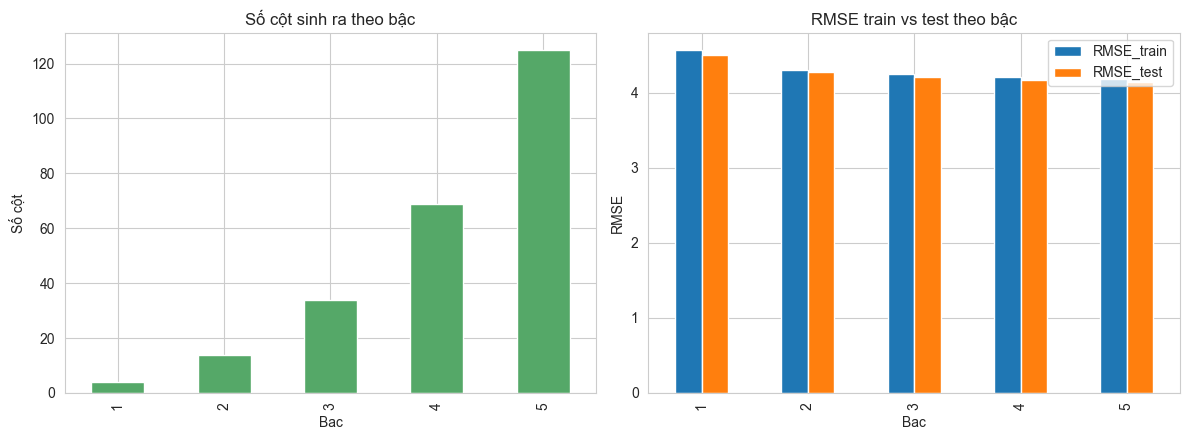

In [12]:
print("=== Bảng tổng hợp: bậc | số cột sinh ra | RMSE train | RMSE test ===")
print(degree_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
degree_table["So_cot_sinh_ra"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("Số cột sinh ra theo bậc")
axes[0].set_ylabel("Số cột")

degree_table[["RMSE_train", "RMSE_test"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE train vs test theo bậc")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.savefig("reports/bang_bac_so_cot_rmse.png", dpi=150)
plt.show()


## Bước 7 — So sánh Linear vs Ridge ở bậc cao (bậc 4–5) → Ridge cứu được bao nhiêu?
Ở bậc cao, số cột tăng nhanh (bậc 4: 70 cột, bậc 5: 126 cột) trong khi AT-V vốn đã tương
quan 0.84 → đa cộng tuyến giữa các đặc trưng đa thức RẤT nặng. Linear thuần dễ có hệ số
"nổ" (giá trị cực lớn, dấu vô lý) — Ridge phải kiểm soát được việc này.


In [14]:
high_degrees = [4, 5]
compare_rows = []

for d in high_degrees:
    for use_ridge, name in [(False, "Linear"), (True, "Ridge")]:
        pipe = make_pipeline(d, alpha=1.0, use_ridge=use_ridge)
        pipe.fit(X_train, y_train)

        pred_te = pipe.predict(X_test)
        rmse_te = np.sqrt(mean_squared_error(y_test, pred_te))
        r2_te = r2_score(y_test, pred_te)

        coefs = pipe["model"].coef_
        max_abs_coef = np.max(np.abs(coefs))

        compare_rows.append({
            "Bac": d, "Model": name,
            "RMSE_test": round(rmse_te, 4),
            "R2_test": round(r2_te, 4),
            "He_so_lon_nhat_tri_tuyet_doi": round(max_abs_coef, 2),
        })

compare_high_degree = pd.DataFrame(compare_rows).set_index(["Bac", "Model"])
print(compare_high_degree)
compare_high_degree.to_csv("reports/linear_vs_ridge_bac_cao.csv")

print("\n Nếu 'He_so_lon_nhat_tri_tuyet_doi' của Linear >> Ridge ở cùng bậc, đó chính là")
print("   bằng chứng đa cộng tuyến làm hệ số Linear 'nổ' — Ridge kiểm soát được nhờ phạt L2.")


            RMSE_test  R2_test  He_so_lon_nhat_tri_tuyet_doi
Bac Model                                                   
4   Linear     4.0620   0.9431                  1.901197e+06
    Ridge      4.1649   0.9402                  1.132000e+01
5   Linear     3.9369   0.9466                  1.261821e+09
    Ridge      4.1487   0.9407                  9.510000e+00

 Nếu 'He_so_lon_nhat_tri_tuyet_doi' của Linear >> Ridge ở cùng bậc, đó chính là
   bằng chứng đa cộng tuyến làm hệ số Linear 'nổ' — Ridge kiểm soát được nhờ phạt L2.


## Bước 8 — Vẽ lại residual plot của model bậc tối ưu → chữ U đã biến mất chưa?


Model bậc tối ưu (degree=4, Ridge):
  RMSE test : 4.1649
  R2 test   : 0.9402


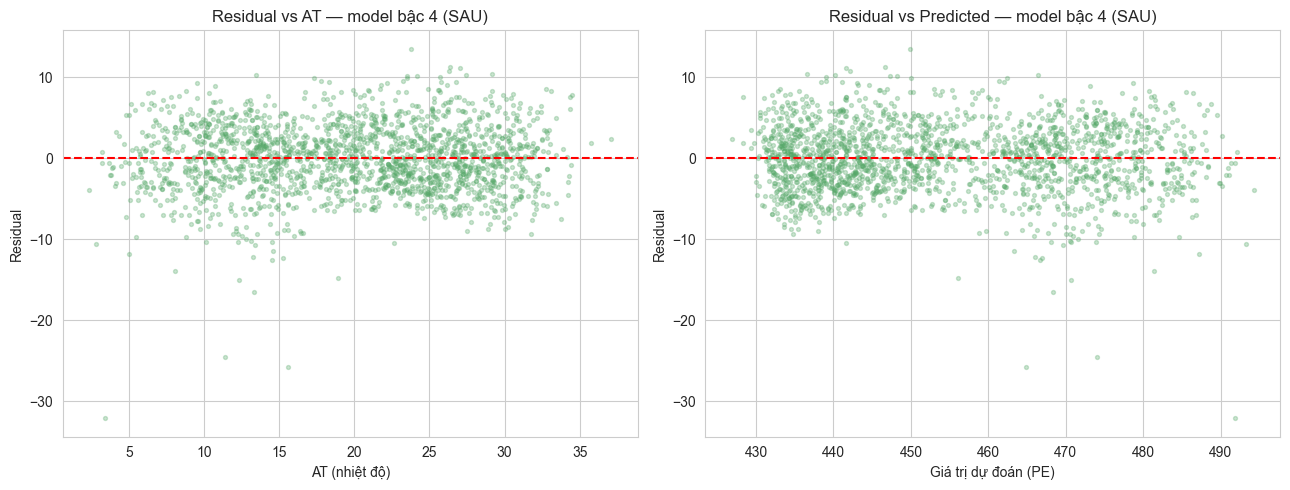


 So sánh trực quan với hình ở Bước 3 (TRƯỚC, bậc 1):
   nếu residual ở đây phân tán ĐỀU quanh 0 (không còn hình chữ U rõ rệt)
   -> xác nhận model bậc tối ưu đã bắt được phần lớn phi tuyến.


In [15]:
best_pipe = make_pipeline(degree=best_degree, alpha=1.0, use_ridge=True)
best_pipe.fit(X_train, y_train)

pred_test_best = best_pipe.predict(X_test)
residuals_best = y_test.values - pred_test_best

rmse_best = np.sqrt(mean_squared_error(y_test, pred_test_best))
r2_best = r2_score(y_test, pred_test_best)
print(f"Model bậc tối ưu (degree={best_degree}, Ridge):")
print(f"  RMSE test : {rmse_best:.4f}")
print(f"  R2 test   : {r2_best:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_test["AT"], residuals_best, s=8, alpha=0.3, color="#55A868")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("AT (nhiệt độ)")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residual vs AT — model bậc {best_degree} (SAU)")

axes[1].scatter(pred_test_best, residuals_best, s=8, alpha=0.3, color="#55A868")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Giá trị dự đoán (PE)")
axes[1].set_ylabel("Residual")
axes[1].set_title(f"Residual vs Predicted — model bậc {best_degree} (SAU)")

plt.tight_layout()
plt.savefig("reports/residual_truoc_sau.png", dpi=150)
plt.show()

print("\n So sánh trực quan với hình ở Bước 3 (TRƯỚC, bậc 1):")
print("   nếu residual ở đây phân tán ĐỀU quanh 0 (không còn hình chữ U rõ rệt)")
print("   -> xác nhận model bậc tối ưu đã bắt được phần lớn phi tuyến.")


## Bước 9 — So sánh với Random Forest Regressor (TT-17)
Cây quyết định bắt phi tuyến một cách tự nhiên (không cần feature engineering thủ công).
So sánh để thấy đánh đổi giữa tính giải thích (Polynomial+Ridge) và độ chính xác thuần tuý (RF).


In [16]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

final_compare = pd.DataFrame({
    "Linear bậc 1 (baseline)": {"RMSE_test": rmse_test_baseline, "R2_test": r2_test_baseline},
    f"Poly bậc {best_degree} + Ridge": {"RMSE_test": rmse_best, "R2_test": r2_best},
    "Random Forest": {"RMSE_test": rmse_rf, "R2_test": r2_rf},
}).T

print(final_compare.round(4))
final_compare.to_csv("reports/so_sanh_poly_vs_rf.csv")

print("\n Nếu RF cho RMSE thấp hơn Poly+Ridge -> đổi lại là mất khả năng giải thích hệ số")
print("   (Poly+Ridge biết rõ 'x² có hệ số bao nhiêu', RF thì không có công thức tường minh).")
print(f"   Chênh lệch RMSE (RF so với Poly bậc {best_degree}):"
      f" {rmse_best - rmse_rf:.4f} MW ({(rmse_best - rmse_rf) / rmse_best * 100:.2f}%)")


                         RMSE_test  R2_test
Linear bậc 1 (baseline)     4.5026   0.9301
Poly bậc 4 + Ridge          4.1649   0.9402
Random Forest               3.2292   0.9640

 Nếu RF cho RMSE thấp hơn Poly+Ridge -> đổi lại là mất khả năng giải thích hệ số
   (Poly+Ridge biết rõ 'x² có hệ số bao nhiêu', RF thì không có công thức tường minh).
   Chênh lệch RMSE (RF so với Poly bậc 4): 0.9357 MW (22.47%)


## Bước 10 —  Diễn giải: ở dải nhiệt độ nào công suất giảm nhanh nhất?

Dùng đạo hàm của model bậc tối ưu theo AT (giữ V, AP, RH ở giá trị trung vị) để xem
tốc độ giảm công suất theo nhiệt độ thay đổi thế nào qua các dải nhiệt độ khác nhau —
đây là câu trả lời định lượng, không phải chỉ nhìn scatter rồi đoán.


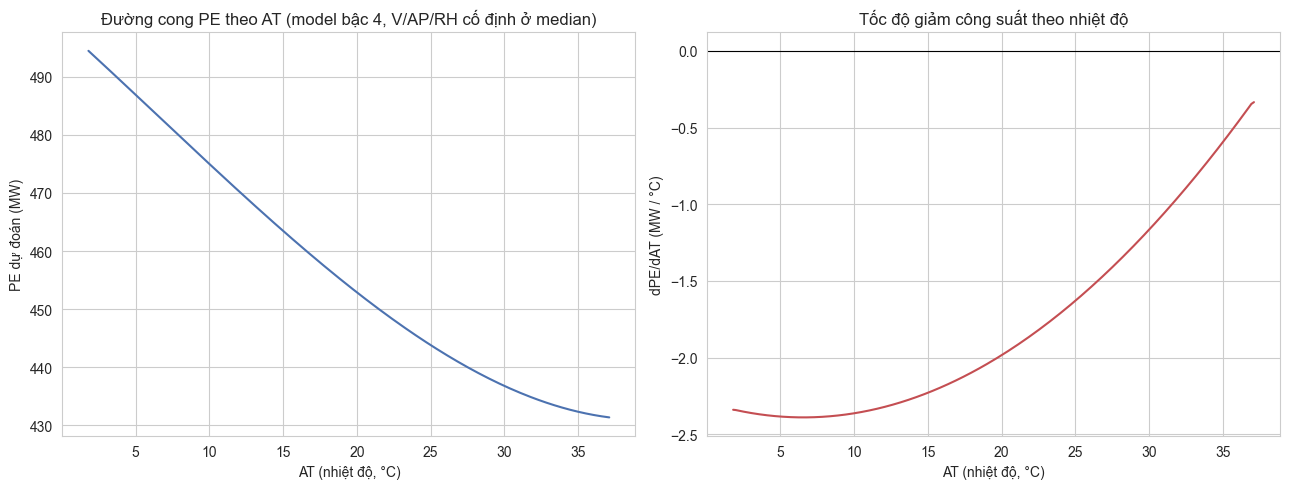

 Công suất giảm NHANH NHẤT quanh AT ≈ 6.6°C (dPE/dAT = -2.389 MW/°C tại điểm đó).
   Dùng con số này để viết vào README: đây là dải nhiệt độ nhà máy cần đặc biệt
   thận trọng khi chào giá công suất, vì sai số dự báo ở vùng này ảnh hưởng lớn nhất.


In [17]:
# Giữ V, AP, RH cố định ở giá trị trung vị, chỉ thay đổi AT để xem PE dự đoán thay đổi ra sao
at_range = np.linspace(df["AT"].min(), df["AT"].max(), 200)
fixed_values = {
    "V": df["V"].median(),
    "AP": df["AP"].median(),
    "RH": df["RH"].median(),
}

sweep_df = pd.DataFrame({
    "AT": at_range,
    "V": fixed_values["V"],
    "AP": fixed_values["AP"],
    "RH": fixed_values["RH"],
})[FEATURES]

pe_pred_sweep = best_pipe.predict(sweep_df)

# Đạo hàm số (gradient) của PE theo AT -> tốc độ thay đổi công suất theo nhiệt độ
dPE_dAT = np.gradient(pe_pred_sweep, at_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(at_range, pe_pred_sweep, color="#4C72B0")
axes[0].set_xlabel("AT (nhiệt độ, °C)")
axes[0].set_ylabel("PE dự đoán (MW)")
axes[0].set_title(f"Đường cong PE theo AT (model bậc {best_degree}, V/AP/RH cố định ở median)")

axes[1].plot(at_range, dPE_dAT, color="#C44E52")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("AT (nhiệt độ, °C)")
axes[1].set_ylabel("dPE/dAT (MW / °C)")
axes[1].set_title("Tốc độ giảm công suất theo nhiệt độ")

plt.tight_layout()
plt.savefig("reports/do_thi_dPE_dAT.png", dpi=150)
plt.show()

steepest_idx = np.argmin(dPE_dAT)  # âm nhất = giảm nhanh nhất
steepest_AT = at_range[steepest_idx]
print(f" Công suất giảm NHANH NHẤT quanh AT ≈ {steepest_AT:.1f}°C"
      f" (dPE/dAT = {dPE_dAT[steepest_idx]:.3f} MW/°C tại điểm đó).")
print("   Dùng con số này để viết vào README: đây là dải nhiệt độ nhà máy cần đặc biệt")
print("   thận trọng khi chào giá công suất, vì sai số dự báo ở vùng này ảnh hưởng lớn nhất.")


## Mở rộng 1 — `interaction_only=True`: chỉ tạo tích chéo, không tạo bậc cao
So sánh với `PolynomialFeatures` đầy đủ ở cùng bậc.


In [18]:
pipe_interaction = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
pipe_interaction.fit(X_train, y_train)
pred_interaction = pipe_interaction.predict(X_test)
rmse_interaction = np.sqrt(mean_squared_error(y_test, pred_interaction))

pipe_full_deg2 = make_pipeline(degree=2, alpha=1.0, use_ridge=True)
pipe_full_deg2.fit(X_train, y_train)
pred_full_deg2 = pipe_full_deg2.predict(X_test)
rmse_full_deg2 = np.sqrt(mean_squared_error(y_test, pred_full_deg2))

print("So sánh ở bậc 2:")
print(f"  Full polynomial (có x²)     : {pipe_full_deg2['poly'].n_output_features_} cột, RMSE = {rmse_full_deg2:.4f}")
print(f"  Interaction only (chỉ x·y)  : {pipe_interaction['poly'].n_output_features_} cột, RMSE = {rmse_interaction:.4f}")
print("\n Nếu RMSE interaction_only gần bằng full polynomial nhưng ít cột hơn nhiều,")
print("   nghĩa là phần lớn phi tuyến đến từ TƯƠNG TÁC giữa biến, không phải từ luỹ thừa riêng lẻ.")


So sánh ở bậc 2:
  Full polynomial (có x²)     : 14 cột, RMSE = 4.2790
  Interaction only (chỉ x·y)  : 10 cột, RMSE = 4.3109

 Nếu RMSE interaction_only gần bằng full polynomial nhưng ít cột hơn nhiều,
   nghĩa là phần lớn phi tuyến đến từ TƯƠNG TÁC giữa biến, không phải từ luỹ thừa riêng lẻ.


## Mở rộng 2 — Thử `SplineTransformer`: linh hoạt hơn đa thức, không "phát điên" khi ngoại suy


In [19]:
pipe_spline = Pipeline([
    ("spline", SplineTransformer(n_knots=5, degree=3)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
pipe_spline.fit(X_train, y_train)
pred_spline = pipe_spline.predict(X_test)
rmse_spline = np.sqrt(mean_squared_error(y_test, pred_spline))
r2_spline = r2_score(y_test, pred_spline)

print(f"Spline (n_knots=5, degree=3) + Ridge:")
print(f"  RMSE test : {rmse_spline:.4f}")
print(f"  R2 test   : {r2_spline:.4f}")
print(f"\nSo với Polynomial bậc {best_degree} + Ridge: RMSE = {rmse_best:.4f}")


Spline (n_knots=5, degree=3) + Ridge:
  RMSE test : 4.1497
  R2 test   : 0.9406

So với Polynomial bậc 4 + Ridge: RMSE = 4.1649


## Mở rộng 3 — Chứng minh hiện tượng ngoại suy: dự đoán ở AT = 50°C bằng bậc 5
Dải dữ liệu thật của AT chỉ trong khoảng quan sát dưới đây — AT = 50°C nằm HẲN ngoài dải này.


In [20]:
print(f"Dải AT thực tế trong dữ liệu: [{df['AT'].min()}, {df['AT'].max()}] °C")

extreme_point = pd.DataFrame({
    "AT": [50.0],
    "V": [df["V"].median()],
    "AP": [df["AP"].median()],
    "RH": [df["RH"].median()],
})[FEATURES]

pipe_degree5 = make_pipeline(degree=5, alpha=1.0, use_ridge=True)
pipe_degree5.fit(X_train, y_train)
pred_extreme_deg5 = pipe_degree5.predict(extreme_point)[0]
pred_extreme_deg1 = baseline_pipe.predict(extreme_point)[0]
pred_extreme_spline = pipe_spline.predict(extreme_point)[0]

print(f"\nDự đoán PE tại AT=50°C (ngoài dải dữ liệu):")
print(f"  Linear bậc 1         : {pred_extreme_deg1:.2f} MW")
print(f"  Polynomial bậc 5     : {pred_extreme_deg5:.2f} MW")
print(f"  Spline               : {pred_extreme_spline:.2f} MW")
print(f"\nKhoảng giá trị PE hợp lý trong dữ liệu: [{df['PE'].min()}, {df['PE'].max()}] MW")
print(" Nếu dự đoán bậc 5 nằm NGOÀI khoảng hợp lý này (hoặc chênh lệch rất lớn so với bậc 1")
print("   và Spline) -> minh chứng rõ ràng cho cảnh báo README: 'đa thức bậc cao PHÁT ĐIÊN")
print("   khi ngoại suy ngoài dải dữ liệu huấn luyện'.")


Dải AT thực tế trong dữ liệu: [1.81, 37.11] °C

Dự đoán PE tại AT=50°C (ngoài dải dữ liệu):
  Linear bậc 1         : 394.34 MW
  Polynomial bậc 5     : 431.20 MW
  Spline               : 435.33 MW

Khoảng giá trị PE hợp lý trong dữ liệu: [420.26, 495.76] MW
 Nếu dự đoán bậc 5 nằm NGOÀI khoảng hợp lý này (hoặc chênh lệch rất lớn so với bậc 1
   và Spline) -> minh chứng rõ ràng cho cảnh báo README: 'đa thức bậc cao PHÁT ĐIÊN
   khi ngoại suy ngoài dải dữ liệu huấn luyện'.


## Lưu model đã huấn luyện

In [21]:
joblib.dump(best_pipe, "models/poly_pipeline.joblib")
print(f"Đã lưu models/poly_pipeline.joblib (degree={best_degree}, Ridge)")


Đã lưu models/poly_pipeline.joblib (degree=4, Ridge)
